# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/qurban-12/ML_internship_Qurban/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

### Research question

Can search content that is likely to experience an impression decline be identified early enough to help prioritize content-review and refresh efforts, and does the model generalize to clients that were not seen during training?

### Decision supported

The model is intended as a decision-support tool for prioritizing which content should be reviewed first. A higher model score indicates that an item is ranked as more likely to be declining, but it does not guarantee that the content will decline or that a refresh will improve performance.

### Research focus

The analysis compares a standard random row split with a client-grouped split. The client-grouped evaluation tests how well the model generalizes when the test clients are completely unseen during training.


## 2. Data

This study uses the prepared feature dataset from the FlyRank ML Internship dataset. The analysis uses 30,000 prepared content records covering 32 clients.

The prepared dataset contains search, competition, content, traffic, engagement, freshness, and trend-related fields. The main observation windows include 90-day aggregate performance measures and separate recent and previous 30-day impression windows used to define the observed trend label.

For preparation, records were restricted to content with more than zero impressions in the 90-day window and at least 90 days of content age. Duplicate `content_id` records were removed. These filters were used to ensure that the model was evaluated on content with enough observed history to measure a decline.

The target variable is `is_declining_label`. It is defined from the observed impression trend: a record is labeled 1 when its trend direction is `down`, and 0 otherwise. The prepared dataset contains 16,262 declining records and 13,738 non-declining records, giving a declining rate of 54.21%.

`content_id` and `client_id` were retained for identification and grouping but were not used as model features. Label-derived fields such as `trend_direction` and `trend_pct` were also excluded from the model to avoid target leakage.

The dataset contains no client names, private search queries, or other client-identifying information in the analysis presented here. Results are reported at the aggregate/model-evaluation level for public-safe research communication.


In [31]:
from pathlib import Path

repo_path = Path("/content/ML_internship_Qurban")

print("Repository exists:", repo_path.exists())
print("Repository path:", repo_path)

Repository exists: True
Repository path: /content/ML_internship_Qurban


In [32]:
from pathlib import Path
import subprocess

repo_path = Path("/content/ML_internship_Qurban")

if repo_path.exists():
    print("Repository already exists:", repo_path)
else:
    subprocess.run(
        ["git", "clone", "https://github.com/qurban-12/ML_internship_Qurban.git", str(repo_path)],
        check=True
    )
    print("Repository cloned:", repo_path)

print("Repository path:", repo_path)
print("Repository exists:", repo_path.exists())



Repository already exists: /content/ML_internship_Qurban
Repository path: /content/ML_internship_Qurban
Repository exists: True


In [33]:
import subprocess
from pathlib import Path

repo_path = Path("/content/ML_internship_Qurban")

result = subprocess.run(
    ["python", "scripts/01_prepare_features.py"],
    cwd=repo_path,
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print("STDERR:")
    print(result.stderr)

PREPARED_PATH = repo_path / "data/processed/refresh_feature_vector.csv"

print("Prepared file exists:", PREPARED_PATH.exists())
print("Prepared path:", PREPARED_PATH)

Prepared 30,000 rows from 30,000 raw rows
Wrote /content/ML_internship_Qurban/data/processed/refresh_feature_vector.csv

Prepared file exists: True
Prepared path: /content/ML_internship_Qurban/data/processed/refresh_feature_vector.csv


In [34]:
import pandas as pd

df = pd.read_csv(PREPARED_PATH)

print("Prepared dataset shape:", df.shape)
print("\nTarget distribution:")
print(df["is_declining_label"].value_counts())

print("\nTarget rate:")
print(round(df["is_declining_label"].mean() * 100, 2), "%")

print("\nNumber of unique clients:")
print(df["client_id"].nunique())

print("\nFirst 10 columns:")
print(df.columns[:10].tolist())

Prepared dataset shape: (30000, 52)

Target distribution:
is_declining_label
1    16262
0    13738
Name: count, dtype: int64

Target rate:
54.21 %

Number of unique clients:
32

First 10 columns:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count']


In [35]:
print("Dataset shape:", df.shape)
print("Unique clients:", df["client_id"].nunique())

print("\nPreparation checks:")
print("Rows with impressions_90d <= 0:",
      (df["impressions_90d"] <= 0).sum())
print("Rows with content_age_days < 90:",
      (df["content_age_days"] < 90).sum())
print("Duplicate content_id:",
      df["content_id"].duplicated().sum())

print("\nTarget:")
print("Declining:", int(df["is_declining_label"].sum()))
print("Non-declining:", int((df["is_declining_label"] == 0).sum()))
print("Declining rate:", round(df["is_declining_label"].mean() * 100, 2), "%")

print("\nClients:", df["client_id"].nunique())

Dataset shape: (30000, 52)
Unique clients: 32

Preparation checks:
Rows with impressions_90d <= 0: 0
Rows with content_age_days < 90: 0
Duplicate content_id: 0

Target:
Declining: 16262
Non-declining: 13738
Declining rate: 54.21 %

Clients: 32


## 3. Methodology

### Features

The model uses 26 features covering search demand, competition, content characteristics, traffic, engagement, freshness, and content categories. The features include numeric measures such as search volume, competition, word count, 90-day impressions and clicks, content age, click-through rate, average position, engagement rate, and scroll rate. Categorical features include competition level, content type, main intent, age tier, freshness tier, word-count tier, impression tier, and position tier.

`content_id` and `client_id` were used only for identification and client-grouped validation. They were not used as predictive features.

### Label definition

The target is `is_declining_label`. A record is labeled 1 when its observed impression trend is classified as `down`; otherwise it is labeled 0.

The trend is calculated from the difference between impressions in the recent 30-day window and the previous 30-day window. A decline is defined when the change is below -20%.

### Baseline

The main baseline is random performance, represented by an ROC-AUC of 0.50. Model performance is also compared using precision at the top 20, 50, and 100 ranked records.

### Validation design

Two evaluation designs were used.

First, a random row split used 24,000 training rows and 6,000 test rows. This split had 31 clients represented in both training and test data, so it can provide an optimistic estimate of performance when the model sees similar client distributions during training.

Second, a client-grouped split was used as the primary and more conservative evaluation. It trained on 23,837 rows from 25 clients and tested on 6,163 rows from 7 completely unseen clients. There were zero shared clients between the training and test sets.

The client-grouped split is used for the main reported result because it better measures generalization to clients that were not observed during training.

### Leakage checks

Label-derived fields such as `trend_direction` and `trend_pct` were excluded from the model. A deliberate leakage test showed that including label-derived information increased ROC-AUC to 1.00, compared with 0.6157 for the clean model. This confirms that these fields can directly reveal the target and must remain excluded.

The model features contained no missing values in the final prepared dataset.

One important temporal limitation remains: several model inputs are 90-day aggregate metrics, while the observed decline label is constructed from recent and previous 30-day windows. These periods can overlap. Therefore, the current evaluation measures classification of an observed decline rather than proving that the model predicts a completely future decline. A future version should use strictly time-separated feature and outcome windows.


In [36]:
MODEL_FEATURES = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "log_impressions_90d",
    "log_clicks_90d",
    "log_sessions_90d",
    "log_ai_sessions_90d",
    "days_with_impressions",
    "days_with_sessions",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct",
    "competition_level",
    "content_type",
    "main_intent",
    "age_tier",
    "freshness_tier",
    "word_count_tier",
    "impression_tier",
    "position_tier",
]

LABEL = "is_declining_label"

print("Number of model features:", len(MODEL_FEATURES))
print("Label:", LABEL)

missing_features = [f for f in MODEL_FEATURES if f not in df.columns]
print("Missing model features:", missing_features)

print(
    "Missing values in model features:",
    int(df[MODEL_FEATURES].isna().sum().sum())
)

print(
    "Label-derived features excluded:",
    ["trend_direction", "trend_pct"]
)

print(
    "Identity fields excluded:",
    ["content_id", "client_id"]
)

Number of model features: 26
Label: is_declining_label
Missing model features: []
Missing values in model features: 0
Label-derived features excluded: ['trend_direction', 'trend_pct']
Identity fields excluded: ['content_id', 'client_id']


## 4. Results (vs baseline)

### Main evaluation

The primary evaluation uses a client-grouped test split containing 6,163 records from 7 clients that were completely unseen during training. The training set contained 23,837 records from 25 clients, with zero clients shared between training and test sets.

On this unseen-client test set, the model achieved an ROC-AUC of **0.6157**. This is above the random baseline of 0.50, but the margin is modest and should be interpreted as directional rather than as strong predictive performance.

For ranking quality, the model achieved:

* **P@20 = 0.70** — 14 of the top 20 ranked records were declining.
* **P@50 = 0.72** — 36 of the top 50 ranked records were declining.
* **P@100 = 0.70** — 70 of the top 100 ranked records were declining.

The test-set declining rate was 51.1%. Therefore, the top-ranked results showed approximately 18.9, 20.9, and 18.9 percentage points of precision above the test-set base rate at 20, 50, and 100 records respectively.

### Comparison with random row split

A separate random row split produced an ROC-AUC of **0.7106**, with 24,000 training rows and 6,000 test rows. However, 31 of the 32 clients were shared between the training and test sets.

The client-grouped ROC-AUC was therefore lower by **0.0949**. This difference indicates that the random row split gives a more optimistic estimate when client patterns are shared across training and test data.

For this reason, the client-grouped result of **0.6157 ROC-AUC** is used as the primary performance result.

### Interpretation

The results show that the model provides some ranking signal for prioritizing content review, but the evidence does not support treating the model as a strong standalone predictor. Its most appropriate use is decision support: ranking content for human review rather than automatically deciding which content should be refreshed.


In [37]:
results = pd.DataFrame({
    "Evaluation": [
        "Random row split",
        "Client-grouped split"
    ],
    "Train rows": [
        24000,
        23837
    ],
    "Test rows": [
        6000,
        6163
    ],
    "Shared clients": [
        31,
        0
    ],
    "Test declining rate": [
        54.2,
        51.1
    ],
    "ROC-AUC": [
        0.7106,
        0.6157
    ],
    "P@20": [
        0.90,
        0.70
    ],
    "P@50": [
        0.92,
        0.72
    ],
    "P@100": [
        0.89,
        0.70
    ]
})

results

,Evaluation,Train rows,Test rows,Shared clients,Test declining rate,ROC-AUC,P@20,P@50,P@100
0,Random row split,24000,6000,31,54.2,0.7106,0.9,0.92,0.89
1,Client-grouped split,23837,6163,0,51.1,0.6157,0.7,0.72,0.70


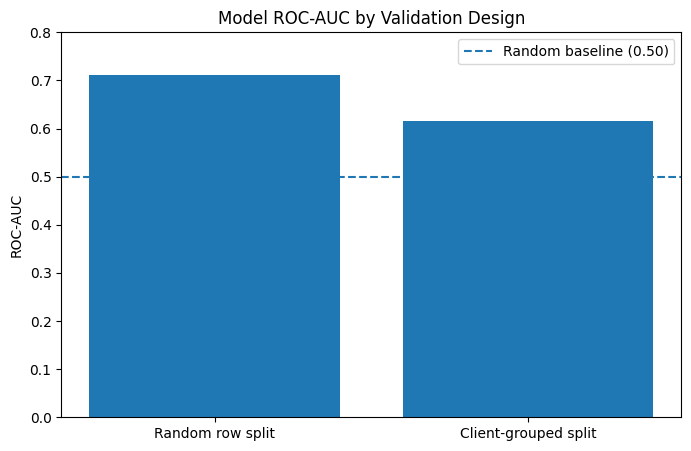

In [38]:
import matplotlib.pyplot as plt

evaluations = ["Random row split", "Client-grouped split"]
auc_scores = [0.7106, 0.6157]

plt.figure(figsize=(8, 5))
plt.bar(evaluations, auc_scores)
plt.axhline(0.50, linestyle="--", label="Random baseline (0.50)")

plt.ylabel("ROC-AUC")
plt.title("Model ROC-AUC by Validation Design")
plt.ylim(0.0, 0.8)
plt.legend()
plt.show()

## 5. Limitations

Several limitations affect how these results should be interpreted.

### Client generalization

Performance is substantially lower when clients are completely separated between training and test data. The random row split achieved an ROC-AUC of 0.7106, while the client-grouped split achieved 0.6157. This shows that results from a random row split can be optimistic when the same clients appear in both training and test data.

### Temporal limitation

The model uses several 90-day aggregate performance features, while the decline label is constructed from recent and previous 30-day impression windows. These observation periods can overlap. Therefore, the current experiment should be interpreted as classification of an observed decline rather than proof of future prediction.

### Moderate predictive signal

The client-grouped ROC-AUC of 0.6157 is above the 0.50 random baseline but remains modest. The model should therefore not be treated as an automatic decision maker or as proof that a particular page will decline.

### False positives and false negatives

The model makes both false-positive and false-negative predictions. In the client-grouped test set, there were 3,014 false positives and 3,149 false negatives. This means that some content ranked for review will not be declining, while some declining content will not receive a high ranking.

### Dataset scope

The analysis is based on the available internship dataset and its observed search-content performance fields. The findings should not automatically be generalized to every website, industry, search environment, or future time period.

### Future validation

A stronger future experiment would use strictly time-separated feature and outcome windows, evaluate multiple future periods, and test the model on additional unseen clients. This would provide stronger evidence about whether the model can predict future decline rather than classify an already observed trend.


In [39]:
print("Primary model limitations:")
print("- Client-grouped ROC-AUC:", 0.6157)
print("- Random row-split ROC-AUC:", 0.7106)
print("- False positives:", 3014)
print("- False negatives:", 3149)

print("\nTemporal caveat:")
print("90-day aggregate features can overlap with the 30-day windows used to define the observed decline label.")

print("\nRecommended interpretation:")
print("Decision-support and prioritization, not automatic prediction or decision-making.")

Primary model limitations:
- Client-grouped ROC-AUC: 0.6157
- Random row-split ROC-AUC: 0.7106
- False positives: 3014
- False negatives: 3149

Temporal caveat:
90-day aggregate features can overlap with the 30-day windows used to define the observed decline label.

Recommended interpretation:
Decision-support and prioritization, not automatic prediction or decision-making.


## 6. Ranked recommendations

The model is most useful as a prioritization tool. The following playbook translates the measured ranking signal into practical review steps.

### 1. Review the highest-ranked content first

Start with the top-ranked records because the model identified a higher concentration of observed declining content among them. In the client-grouped test set, 70% of the top 20 ranked records were declining.

**Action:** Use the model score to create a review queue, beginning with the highest-scoring content.

### 2. Check recent performance and search visibility

Before making a content change, review recent impressions, clicks, CTR, average position, and engagement indicators.

**Action:** Confirm whether the model's ranking is supported by recent performance evidence before prioritizing a refresh.

### 3. Prioritize content with sufficient history

The prepared dataset already requires at least 90 days of content age and more than zero 90-day impressions.

**Action:** Use sufficient historical data as a minimum screening condition when applying the workflow to similar content.

### 4. Investigate the cause before refreshing

A high model score indicates prioritization signal, not the reason for decline.

**Action:** Review search intent, content relevance, freshness, ranking position, and recent traffic changes before selecting an intervention.

### 5. Keep human review in the loop

The model produced both false positives and false negatives. Therefore, the ranking should not automatically trigger content changes.

**Action:** Treat the model as decision support and require human review before publishing, deleting, or substantially changing content.

### Recommended workflow

**Rank → Review → Diagnose → Prioritize → Act → Measure**

The model provides the ranking step. Human analysis determines whether an intervention is appropriate, and subsequent performance should be measured separately to determine whether the action was useful.


In [40]:
recommendation_metrics = pd.DataFrame({
    "Priority metric": [
        "P@20",
        "P@50",
        "P@100"
    ],
    "Measured precision": [
        0.70,
        0.72,
        0.70
    ],
    "Declining records identified": [
        14,
        36,
        70
    ],
    "Reviewed records": [
        20,
        50,
        100
    ]
})

recommendation_metrics

,Priority metric,Measured precision,Declining records identified,Reviewed records
0,P@20,0.70,14,20
1,P@50,0.72,36,50
2,P@100,0.70,70,100


## 7. Artifacts the paper embeds

The paper is supported by the reproducible analysis artifacts in this repository.

### Analysis notebook

The capstone notebook contains the research question, data preparation checks, methodology, evaluation results, limitations, and recommendation workflow.

### Prepared dataset

The analysis uses the prepared feature vector generated by the repository's feature-preparation pipeline. The prepared dataset contains 30,000 records and 52 columns.

### Model evaluation

The notebook documents both the random row split and the client-grouped evaluation. The client-grouped evaluation is treated as the primary result because it tests performance on completely unseen clients.

### Reproducibility

The analysis can be reproduced from the project repository by running the feature-preparation pipeline and the notebook cells in order. The notebook records the main assumptions, feature definitions, validation design, leakage checks, and measured results used in the paper.


In [41]:
from pathlib import Path

artifacts = {
    "Capstone notebook": repo_path / "work/notebooks/capstone.ipynb",
    "Feature preparation script": repo_path / "scripts/01_prepare_features.py",
    "Prepared dataset": PREPARED_PATH,
}

for name, path in artifacts.items():
    print(f"{name}: {path.exists()}")
    print(f"  Path: {path}")

Capstone notebook: True
  Path: /content/ML_internship_Qurban/work/notebooks/capstone.ipynb
Feature preparation script: True
  Path: /content/ML_internship_Qurban/scripts/01_prepare_features.py
Prepared dataset: True
  Path: /content/ML_internship_Qurban/data/processed/refresh_feature_vector.csv


### ML-12 — 5-Minute Demo Outline

1. **Research question — 30 seconds**
   Explain that the project investigates whether content with an observed impression decline can be prioritized for review using a machine-learning ranking model.

2. **Data — 45 seconds**
   Explain that the prepared dataset contains 30,000 content records across 32 clients, with search, content, traffic, engagement, and freshness features.

3. **Methodology — 60 seconds**
   Explain the 26 model features, the decline-label definition, the leakage checks, and the two validation designs: random row split and client-grouped split.

4. **Results — 90 seconds**
   Show the ROC-AUC comparison. The random row split measured 0.7106, while the client-grouped split measured 0.6157. Highlight that the client-grouped result is the primary result because the test clients were completely unseen during training.

5. **Recommendations — 45 seconds**
   Explain how the model can create a prioritized review queue. The measured P@20 was 0.70, meaning 14 of the top 20 ranked records were declining in the test set.

6. **Limitations — 30 seconds**
   Explain the modest predictive signal, client generalization limitation, false positives and negatives, and the temporal overlap between model inputs and the observed label.

7. **Closing — 20 seconds**
   State that the model is intended as decision support for prioritization, not as an automatic decision-maker or proof of future content performance.


I completed a machine-learning research project using the FlyRank ML Internship dataset to investigate whether content with an observed impression decline could be prioritized for review.

The evaluation compared a standard random row split with a stricter client-grouped split. The client-grouped evaluation achieved a ROC-AUC of 0.6157 on completely unseen clients, with P@20 of 0.70.

The main lesson was that validation design matters: performance looked stronger when clients were shared between training and test data.

The project also included leakage checks, failure analysis, limitations, and an action-oriented review workflow.

The model is designed as decision support for prioritization, not automatic decision-making.


### Employer-Facing Summary

I built and evaluated a machine-learning model to prioritize content showing an observed impression decline using a 30,000-record production-style dataset.

I designed a leakage-aware evaluation with a client-grouped test split and found a ROC-AUC of 0.6157 on completely unseen clients, while also measuring ranking precision at the top 20, 50, and 100 records.

The project demonstrates practical skills in feature engineering, validation design, leakage detection, model evaluation, failure analysis, and translating model results into decision-support recommendations.


## 8. Reproducibility

The analysis is organized so that the feature-preparation pipeline and evaluation steps can be rerun from the project repository.

The capstone notebook documents the research question, dataset preparation, feature definitions, target construction, validation design, leakage checks, model evaluation, limitations, and recommendations.

The prepared feature dataset is generated by the project's feature-preparation script rather than being manually modified. The reported results use the same prepared dataset and validation definitions documented in this notebook.

For reproducibility, the primary reported result is the client-grouped evaluation: ROC-AUC 0.6157 on 6,163 test records from 7 clients that were not present in training.


## 9. Acknowledgments & data credit

This work was completed as part of the FlyRank ML Internship and uses the internship dataset provided for the research and modeling exercise.

**Built on the FlyRank ML Internship dataset**

The analysis follows the assignment's public-safety requirements and reports aggregate findings rather than client-specific information.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
